# <center> **Titanic Data Analyzing and Visualization** </center>
---

## **About Titanic**

- The Titanic dataset is a popular dataset used for learning data analysis. It has information about people who were on the Titanic ship, like their age, gender, class, and if they survived or not. It helps us understand why some people survived and others did not.

<p align= "center">
    <img src= "titanic_image.jpg", alt= "titanic Imgae", width= 800>
</p>

---

### **Objective**

The objective of this project is to analyze passenger data to understand the factors that influenced survival outcomes. By exploring survival patterns based on **gender, passenger type, passenger class, fare, age, family relationships, and embarkation port**, the project aims to identify key trends and relationships that affected survival probability. This analysis helps uncover insights into how socio-economic status, demographics, and travel characteristics contributed to survival chances.



## <center> **Loading and Viewing Titanic Dataset** </center>

### Import libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


### Load Titanic Dataset

In [3]:
df= pd.read_csv("titanic_dataset.csv")

### First five rows

In [4]:
df.head()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


### Last five rows

In [5]:
df.tail()

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
886,886,0,2,male,27.0,0,0,13.00,S,Second,man,True,Southampton,no,True
887,887,1,1,female,19.0,0,0,30.00,S,First,woman,False,Southampton,yes,True
888,888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,Southampton,no,False
889,889,1,1,male,26.0,0,0,30.00,C,First,man,True,Cherbourg,yes,True
890,890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,Queenstown,no,True


### Random Sample

In [6]:
df.sample(3)

,Unnamed: 0,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
105,105,0,3,male,28.0,0,0,7.8958,S,Third,man,True,Southampton,no,True
403,403,0,3,male,28.0,1,0,15.8500,S,Third,man,True,Southampton,no,False
704,704,0,3,male,26.0,1,0,7.8542,S,Third,man,True,Southampton,no,False


## <center>**Understanding Titanic Dataset**</center>

### Shape (`rows` & `columns`)

In [7]:
df.shape

(891, 15)

### Total columns

In [8]:
for column in df:
    print("- ", column)

-  Unnamed: 0
-  survived
-  pclass
-  sex
-  age
-  sibsp
-  parch
-  fare
-  embarked
-  class
-  who
-  adult_male
-  embark_town
-  alive
-  alone


### Numeric columns
- Integer columns
- Float columns

### Integer columns

In [9]:
numeric_col= df.select_dtypes(include= ['int64', 'int32']).columns
for integer_columns in numeric_col:
    print(integer_columns)

Unnamed: 0
survived
pclass
sibsp
parch


### Float columns

In [10]:
float= df.select_dtypes(include="float").columns
for column in float:
    print(column)


age
fare


### Non-numeric columns

In [11]:
Non_numeric_col= df.select_dtypes(include="object").columns
for object in Non_numeric_col:
    print(object)



sex
embarked
class
who
embark_town
alive


### Columns and their Data Types

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   891 non-null    int64  
 1   survived     891 non-null    int64  
 2   pclass       891 non-null    int64  
 3   sex          891 non-null    object 
 4   age          714 non-null    float64
 5   sibsp        891 non-null    int64  
 6   parch        891 non-null    int64  
 7   fare         891 non-null    float64
 8   embarked     889 non-null    object 
 9   class        891 non-null    object 
 10  who          891 non-null    object 
 11  adult_male   891 non-null    bool   
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(5), object(6)
memory usage: 92.4+ KB


### Number of Missing Values in each columns

In [13]:
df.isnull().sum()

Unnamed: 0       0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

### Percentage of Missing Values in each column

In [14]:
df.isnull().mean() * 100

Unnamed: 0      0.000000
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

### Statistical Summery of Data

In [15]:
df.describe()

,Unnamed: 0,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,445.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,222.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,445.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,667.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,890.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [16]:
df['age'].median()

np.float64(28.0)

## <center> **Data Cleaning and Preprocessing** </center>

In [17]:
df.isnull().sum()

Unnamed: 0       0
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
embark_town      2
alive            0
alone            0
dtype: int64

### Drop Irrelevent Columns

In [18]:
df.drop(columns=["Unnamed: 0","embark_town","alive"],axis=1,inplace=True)

### Fill Missing Values of `Age` column

In [19]:
df["age"].fillna(df["age"].median(),inplace=True)

### Fill Missing Values of `Embarked` column

In [20]:
df["embarked"].fillna(df["embarked"].mode()[0],inplace=True)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   sex         891 non-null    object 
 3   age         891 non-null    float64
 4   sibsp       891 non-null    int64  
 5   parch       891 non-null    int64  
 6   fare        891 non-null    float64
 7   embarked    891 non-null    object 
 8   class       891 non-null    object 
 9   who         891 non-null    object 
 10  adult_male  891 non-null    bool   
 11  alone       891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(4)
memory usage: 71.5+ KB


### Rename `Sex` into `Gender`  

In [22]:
df.rename(columns= {"sex": "gender"}, inplace=True)

### Detecting Outliers 

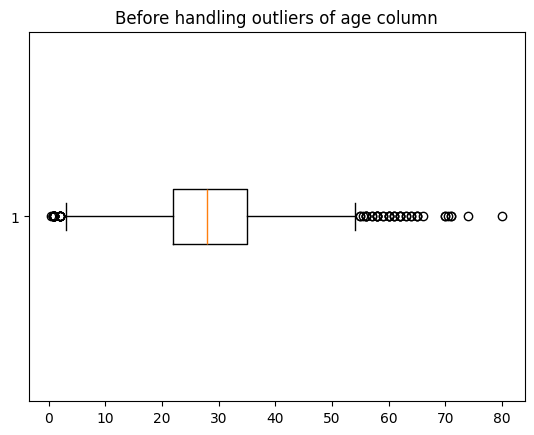

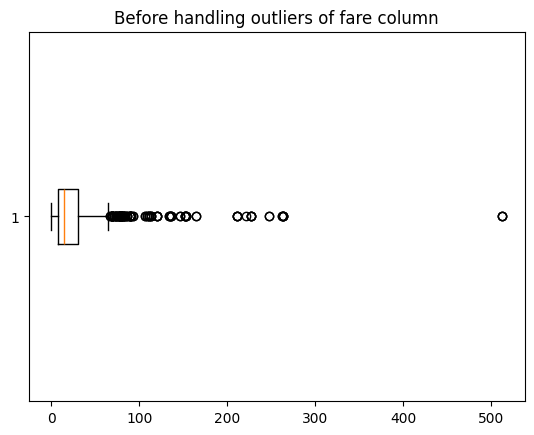

In [23]:
for column in ['age','fare']:
    plt.boxplot(df[column].dropna(), vert= False)
    plt.title(f"Before handling outliers of {column} column")
    plt.show()

### Function for Removing Outliers

In [24]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR=Q3-Q1
    
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    return df[(df[column] >= lower) & (df[column] <= upper)] 
    

In [25]:
df=remove_outliers(df,'age')

In [26]:
df=remove_outliers(df, "fare")

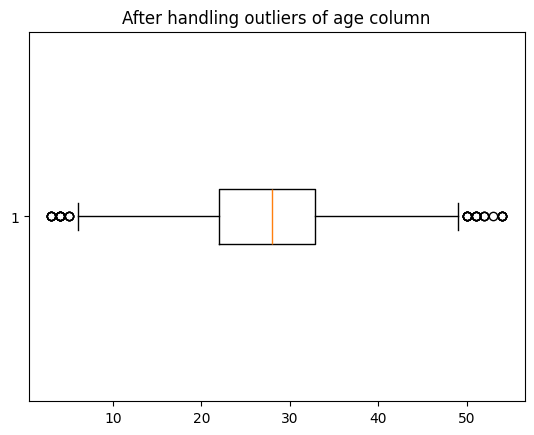

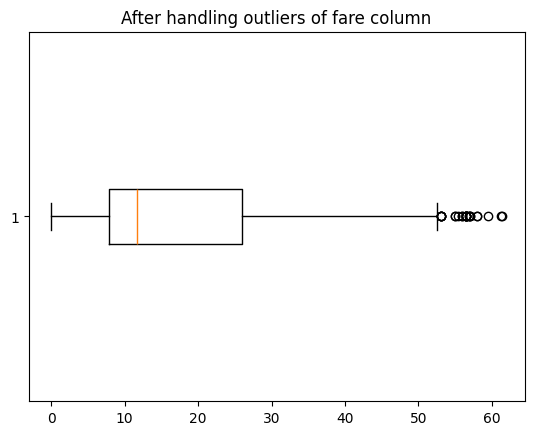

In [27]:
for column in ['age','fare']:
    plt.boxplot(df[column].dropna(), vert= False)
    plt.title(f"After handling outliers of {column} column")
    plt.show()

In [28]:
df.sample(4)

,survived,pclass,gender,age,sibsp,parch,fare,embarked,class,who,adult_male,alone
79,1,3,female,30.0,0,0,12.4750,S,Third,woman,False,True
251,0,3,female,29.0,1,1,10.4625,S,Third,woman,False,False
841,0,2,male,16.0,0,0,10.5000,S,Second,man,True,True
133,1,2,female,29.0,1,0,26.0000,S,Second,woman,False,False


## <center>**Data Visualization of Titanic Dataset**

### **Count of survived and Not-Survived**

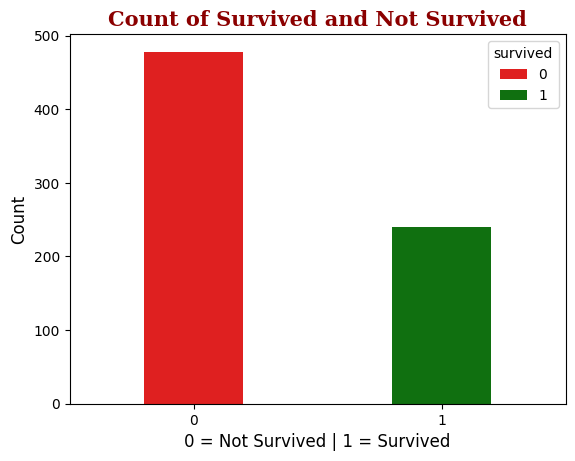

In [29]:
sns.countplot(x= df['survived'], hue= df['survived'], palette= ['r', 'g'], width= 0.4)

title_font={
    "family":"serif",
    "color":"darkred",
    "weight":"bold",
    "size":15
}

lable_font={
    "family":"sans-serif",
    "color":"black",
    "size":12
}

plt.title("Count of Survived and Not Survived", fontdict= title_font)
plt.xlabel("0 = Not Survived | 1 = Survived",fontdict=lable_font)
plt.ylabel("Count",fontdict=lable_font)
plt.show()

### **Insights:**

- Majority of passanger died than survived.
- Overall survival rate is low thats why dataset is imbalanced for Machine Learning.

### **Percentage of Survived and Not Survived**

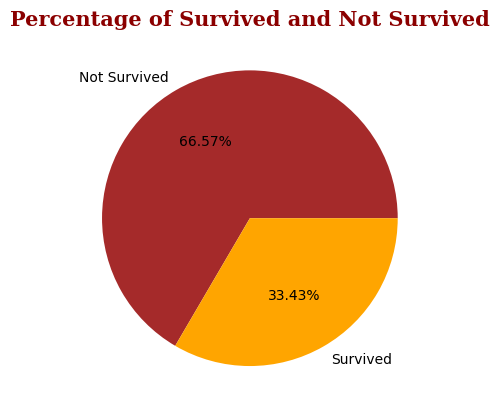

In [30]:
x = df['survived'].value_counts()

plt.pie(
    x.values,
    labels= ['Not Survived', 'Survived'],
    autopct= "%.2f%%",
    colors= ['brown', 'orange']
)
title_font={
    "family":"serif",
    "color":"darkred",
    "weight":"bold",
    "size":15
}
plt.title("Percentage of Survived and Not Survived",fontdict=title_font)
plt.show()

### **Insights:**

- Percentage of Not Survived is 66.57% grater than Survived.
- Because of low(33.43%) percentage of Survived dataset is Imbalanced. 

### **Survival Rate based on Gender**

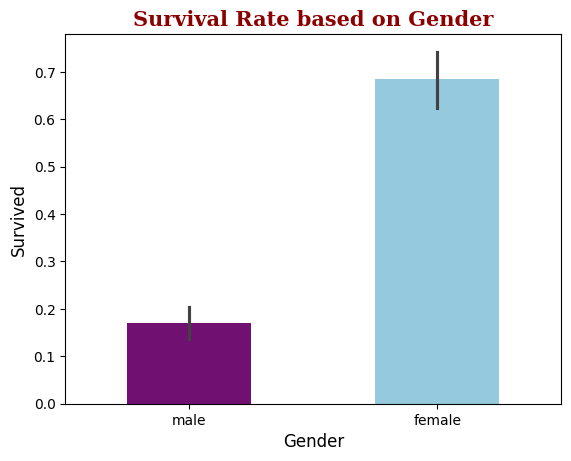

In [31]:
sns.barplot(x=df["gender"],y=df["survived"],hue=df["gender"],palette=["purple","skyblue"],width=0.5)
title_font={
    "family":"serif",
    "color":"darkred",
    "weight":"bold",
    "size":15
}

lable_font={
    "family":"sans-serif",
    "color":"black",
    "size":12
}
plt.title("Survival Rate based on Gender",fontdict=title_font)
plt.xlabel("Gender",fontdict=lable_font)
plt.ylabel("Survived",fontdict=lable_font)
plt.show()

### **Insights:**

- Strength of survived on the based of gender the Survival Rate of Female is grater than Male.

### **Percentage of Survived based on Gender**

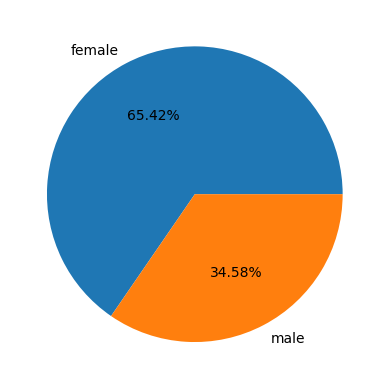

In [32]:
grouped = df.groupby("gender")['survived'].sum()

plt.pie(
    x = grouped.values,
    labels = grouped.index,
    autopct= "%.2f%%"
    )
plt.show()

### **Insights:**

- Female had a higher Survival Percentage than Male. 

### **Not Survived based on Gender**

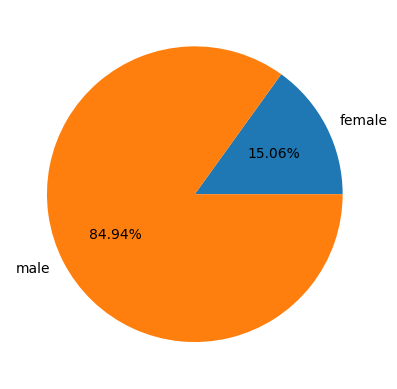

In [33]:
grouped = df[df['survived'] == 0].groupby("gender")['survived'].count()


plt.pie(
    x= grouped.values,
    labels = grouped.index,
    autopct= "%.2f%%"
)
plt.show()

### **Insights:**

- Most non-survivors were male.
- Men had a much higher death rate than women.
- Females were far less likely to die.
- Gender strongly influenced survival outcomes.


### **Survived based on Passanger Type**

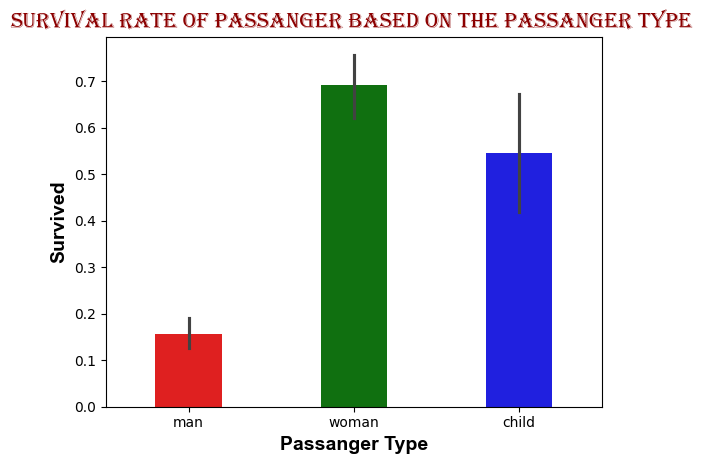

In [34]:
sns.barplot(x=df["who"],y=df["survived"],hue=df["who"],palette=['r','g','b'],width=0.4)
title_font={
    "family":"Algerian",
    "weight":"bold",
    "size":16,
    "color":"darkred"
}
lable_font={
    "family":"Arial",
    "weight":"bold",
    "size":14,
    "color":"black"
}
plt.title("Survival rate of Passanger based on the Passanger Type ",fontdict=title_font)
plt.xlabel("Passanger Type",fontdict=lable_font)
plt.ylabel("Survived",fontdict=lable_font)
plt.show()

### **Insights:**
- Women and children had the highest survival rates.
- Men were less likely to survive.
- Rescue priority favored women and children.


### **Percentage of Survived based on Passanger Type**

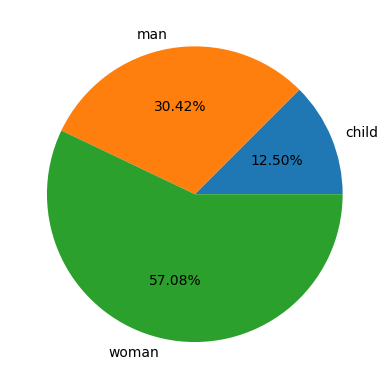

In [35]:
grouped=df.groupby("who")["survived"].sum()

plt.pie(
    x=grouped.values,
    labels=grouped.index,
    autopct="%.2f%%"
)
plt.show()

### **Insights:**

- Women make up the largest percentage of total survivors.
- Men contribute a moderate share of survivors.
- Children have the smallest share of total survivors.
- Distribution reflects both population size and survival priority.


### **Survived based on Passanger Class**

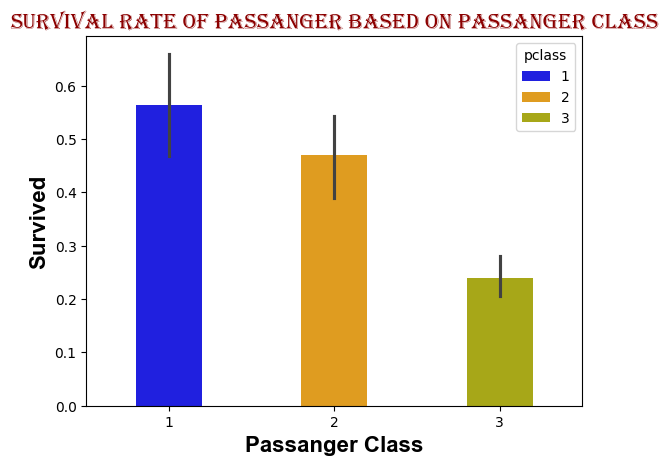

In [36]:
sns.barplot(x=df["pclass"],y=df["survived"],hue=df["pclass"],palette=['b','orange','y'],width=0.4)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Passanger based on Passanger Class',fontdict=title_font)
plt.xlabel('Passanger Class',fontdict=lable_font)
plt.ylabel('Survived',fontdict=lable_font)
plt.show()

### **Insights:**

- 1st-class passengers had the highest survival rate.
- 2nd-class passengers had moderate survival.
- 3rd-class passengers had the lowest survival rate.




### **Percentage of Survived based on Passanger Class**

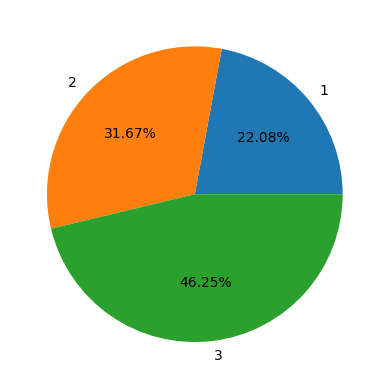

In [37]:
grouped=df.groupby('pclass')['survived'].sum()

plt.pie(
    x=grouped.values,
    labels=grouped.index,
    autopct='%.2f%%'
)
plt.show()


### **Insights:**
- 3rd class Passanger had higher percentage of survivors.
- 2nd Class and 1st class passanger had lower percentage of survivors.

### **Fare based on Passanger Class**

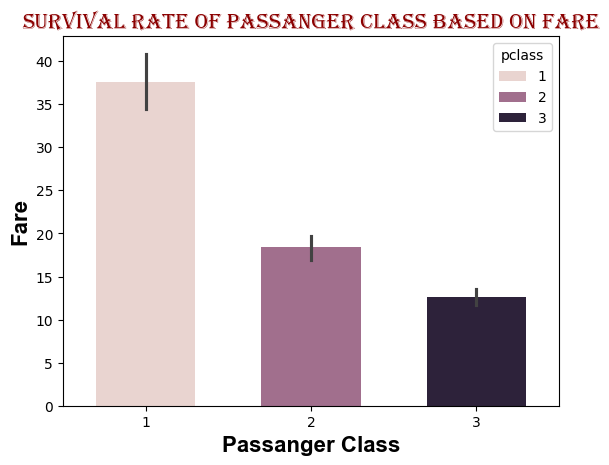

In [38]:
sns.barplot(x=df['pclass'],y=df['fare'],hue=df['pclass'],width=0.6)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Passanger Class based on Fare',fontdict=title_font)
plt.xlabel('Passanger Class',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()

### **Insights:**
- 1st-class passengers paid the highest fares.
- 2nd-class fares were moderate.
- 3rd-class passengers paid the lowest fare.

### **Fare based on Passanger Type**

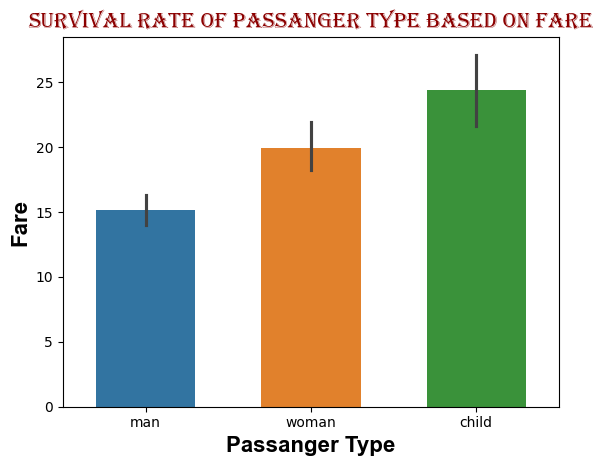

In [39]:
sns.barplot(x=df['who'],y=df['fare'],hue=df['who'],width=0.6)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Passanger Type based on Fare',fontdict=title_font)
plt.xlabel('Passanger Type',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()

### **Insights:**

- Child paid higher fares on average than women and men.
- Women had moderate average fares.
- Men had the lowest average fares.


### **Fare vs Passanger class based on Passanger Type**

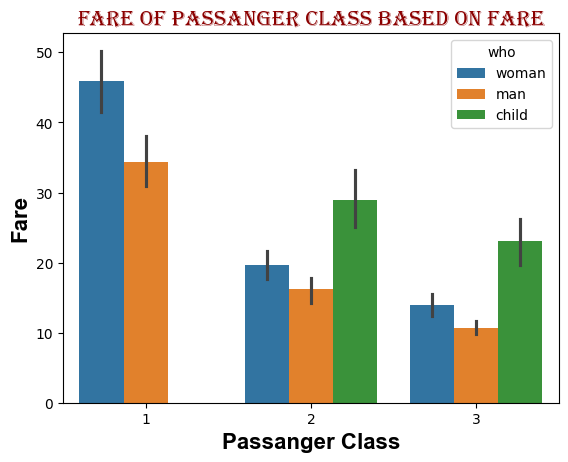

In [ ]:
sns.barplot(x= df['pclass'], y= df['fare'], hue= df['who'])

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Fare of Passanger Class based on Fare',fontdict=title_font)
plt.xlabel('Passanger Class',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()

### **Insights:**
- 1st class highest fares, mostly adults specialy women .
- 2nd class moderate fares, fewer children.
- Children paid less across all classes.


### **Age Distribution**

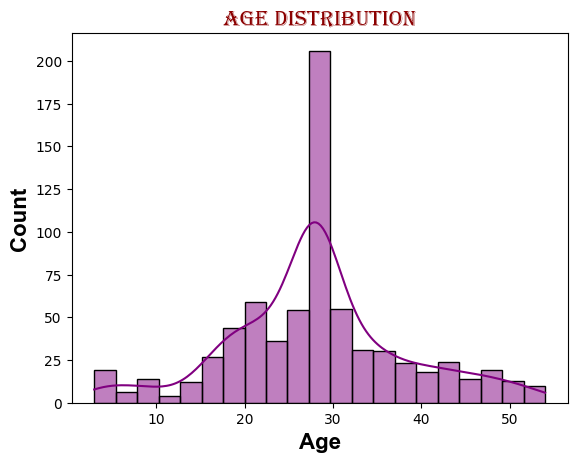

In [58]:
sns.histplot(x= df['age'], color= 'purple', kde= True)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Age Distribution',fontdict=title_font)
plt.xlabel('Age',fontdict=lable_font)
plt.ylabel('Count',fontdict=lable_font)
plt.show()

### **Insights:**
- Most passengers were young adults (20–40 years).
- Few children and elderly passengers on board.
- Slight right skew due to some older passengers.


### **Fare Distribution**

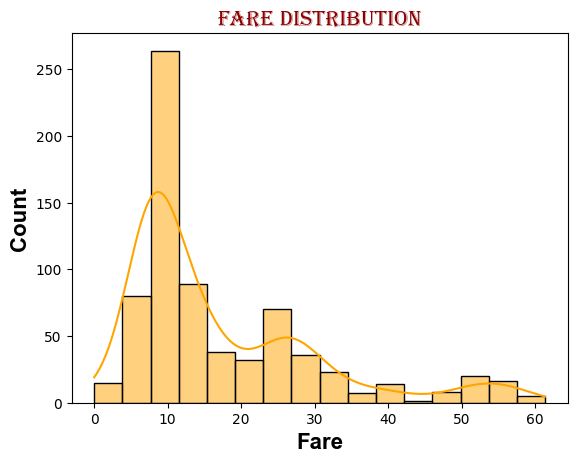

In [59]:
sns.histplot(x=df['fare'],color='orange',kde=True)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Fare Distribution',fontdict=title_font)
plt.xlabel('Fare',fontdict=lable_font)
plt.ylabel('Count',fontdict=lable_font)
plt.show()

### **Insights:**

- Most passengers paid low fares.
- Few passengers paid very high fares (outliers).
- Distribution is heavily right-skewed.


### **Survival Rate of Gender based on Fare**

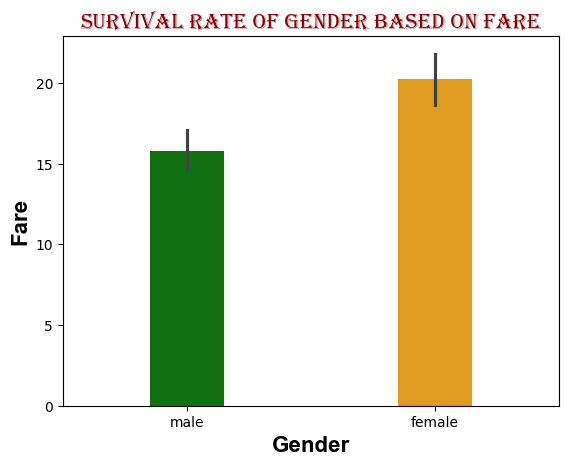

In [43]:
sns.barplot(x=df['gender'],y=df['fare'],hue=df['gender'],palette=['g','orange'],width=0.3)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Gender based on Fare',fontdict=title_font)
plt.xlabel('Gender',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()


### **Insights:**

- Females paid higher fares.
- Males had lower fares.

### **Avarage of Gender based on Fare**

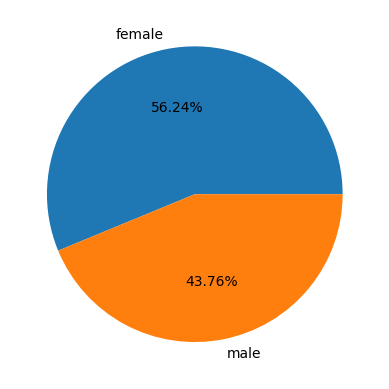

In [44]:
grouped=df.groupby("gender")['fare'].mean()
plt.pie(
    x=grouped.values,
    labels=grouped.index,
    autopct='%.2f%%'

)
plt.show()

### **Insights:**

- Females paid higher percentage of fares on average than males.
- Males had lower percentage average fares.

### **Survival Rate of Passanger Class based on Fare**

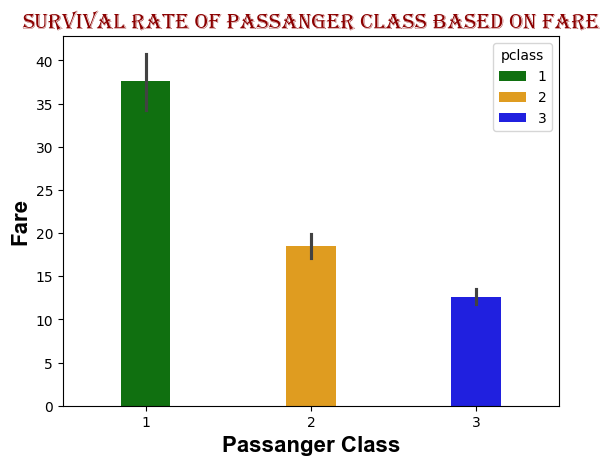

In [45]:
sns.barplot(x=df['pclass'],y=df['fare'],hue=df['pclass'],palette=['g','orange','b'],width=0.3)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Passanger Class based on Fare',fontdict=title_font)
plt.xlabel('Passanger Class',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()

### **Insights:**
- 1st-class passengers paid the highest fares.
- 2nd-class passengers paid moderate fares.
- 3rd-class passengers paid the lowest fares.

### **Avarage of Passanger Class based on Fare**

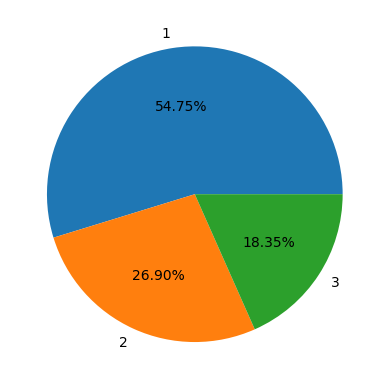

In [46]:
mean_pclass=df.groupby('pclass')['fare'].mean()
plt.pie(
    x=mean_pclass.values,
    labels=mean_pclass.index,
    autopct='%.2f%%'
)
plt.show()

### **Insights:**
- 1st-class passengers paid the highest fares.
- 2nd-class fares were moderate.
- 3rd-class fares were the lowest.

### **Survival Rate of Passanger Type based on Fare**

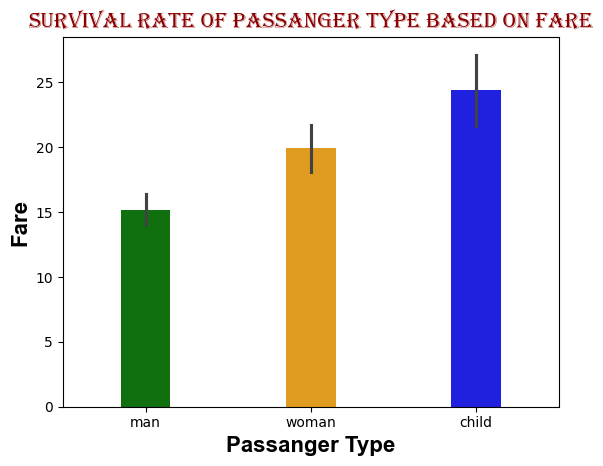

In [47]:
sns.barplot(x=df['who'],y=df['fare'],hue=df['who'],palette=['g','orange','b'],width=0.3)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Passanger Type based on Fare',fontdict=title_font)
plt.xlabel('Passanger Type',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()
plt.show()

### **Insights:**
- Child paid the highest fares.
- Women had moderate fares.
- Men had the lowest fares

### **Avarage of Passanger Type based on Fare**

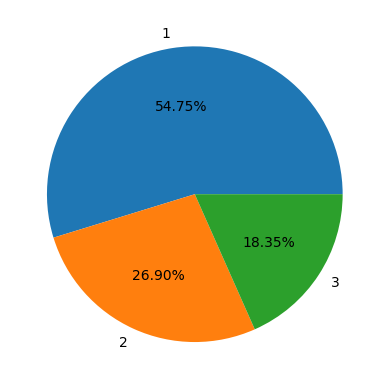

In [48]:
mean_ptype=df.groupby('who')['fare'].mean()
plt.pie(
    x=mean_pclass.values,
    labels=mean_pclass.index,
    autopct='%.2f%%'
)
plt.show()

### **Insights:**
- Women paid the highest fares on average.
- Men had moderate fares.
- Children had the lowest fares.

### **Survival Probability based on Embarked_town**

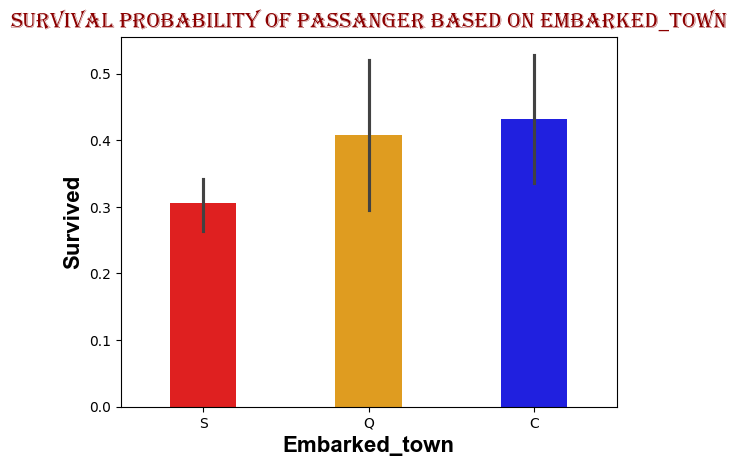

In [49]:
sns.barplot(x=df['embarked'],y=df['survived'],hue=df['embarked'],palette=['r','orange','b'],width=0.4)

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Probability of Passanger based on Embarked_town',fontdict=title_font)
plt.xlabel('Embarked_town',fontdict=lable_font)
plt.ylabel('Survived',fontdict=lable_font)
plt.show()

### **Insights:**
- Passengers from Cherbourg (C) ports had higher survival rates than others.
- Port differences may reflect passenger class distribution and crowding patterns.

### **Survival Probability based on Sibling and Spouse**

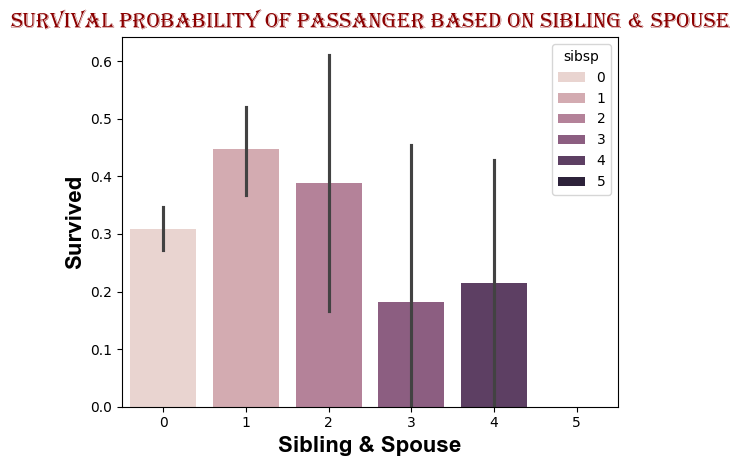

In [50]:
sns.barplot(x=df['sibsp'],y=df['survived'],hue=df['sibsp'])

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Probability of Passanger based on Sibling & Spouse',fontdict=title_font)
plt.xlabel('Sibling & Spouse',fontdict=lable_font)
plt.ylabel('Survived',fontdict=lable_font)
plt.show()

### **Insights:**
- Highest survival among passengers with 1–2 siblings/spouses.
- Lower survival for those traveling alone.
- Sharp decline in survival for large families (≥3).



### **Survival Probability based on Parent and Children**

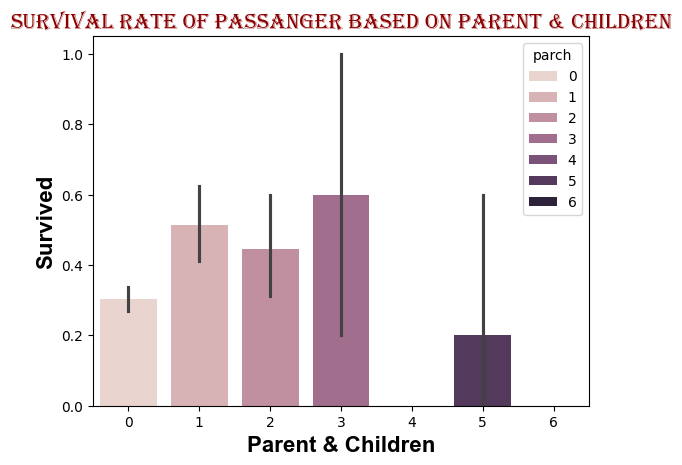

In [51]:
sns.barplot(x=df['parch'],y=df['survived'],hue=df['parch'])

title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title('Survival Rate of Passanger based on Parent & Children',fontdict=title_font)
plt.xlabel('Parent & Children',fontdict=lable_font)
plt.ylabel('Survived',fontdict=lable_font)
plt.show()

### **Insights:**
- Highest survival for passengers with 3–1 parents/children.
- Lower surviva for those traveling alone.
- Survival drops as family size increases (≥3).



### **Age VS Fare** 

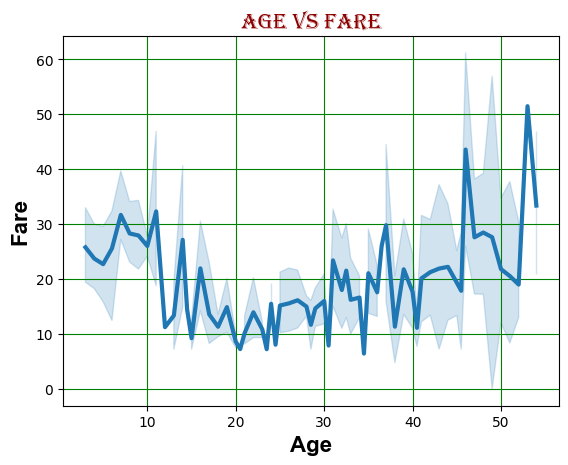

In [52]:
sns.lineplot(x=df['age'],y=df['fare'],lw=3)


title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}

plt.grid(color='g')
plt.title("Age VS Fare",fontdict=title_font)
plt.xlabel("Age",fontdict=lable_font)
plt.ylabel("Fare",fontdict=lable_font)
plt.show()

### **Insights**
- Children paid lower fares, mostly cheap tickets.
- Adults (20–50) show wide fare range across classes.
- Older passengers often paid high fares, likely first-class.


### **Age VS Fare based on Gender**

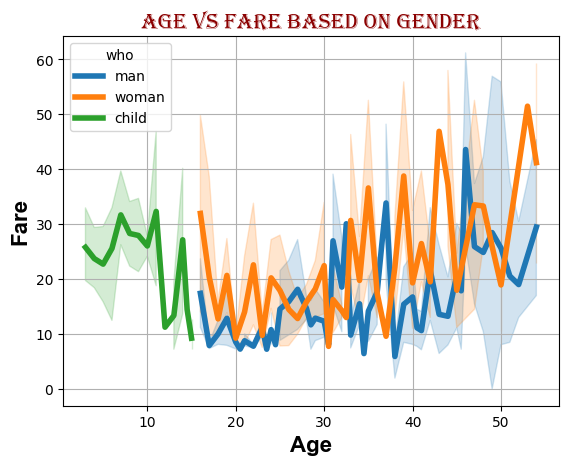

In [53]:
sns.lineplot(x=df['age'],y=df['fare'],hue=df['who'],lw=4)


title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.grid()
plt.title('Age VS Fare based on Gender',fontdict=title_font)
plt.xlabel('Age',fontdict=lable_font)
plt.ylabel('Fare',fontdict=lable_font)
plt.show()

### **Insights**

- Children paid low fares.
- Adults show wide fare variation across classes.
- Older females often paid higher fares than males.


### **Passenger Count by Embarkation Port**


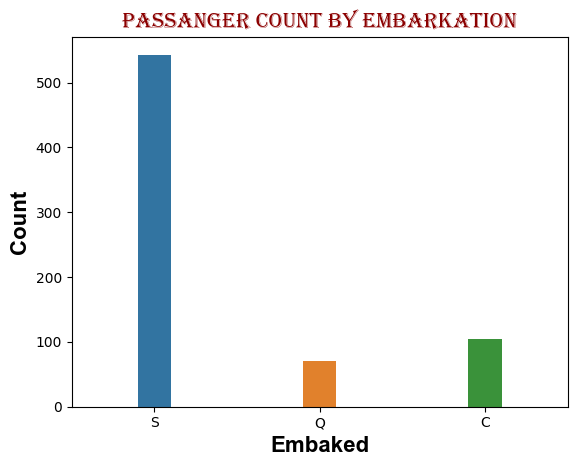

In [56]:
sns.countplot(x=df['embarked'],hue=df['embarked'],width=.2)


title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}
plt.title("Passanger Count by Embarkation",fontdict=title_font)
plt.xlabel("Embaked",fontdict=lable_font)
plt.ylabel("Count",fontdict=lable_font)
plt.show()

### **Insights:**

- Most passengers boarded at Southampton (S).
- Fewer passengers boarded at Cherbourg (C) and Queenstown (Q).



### **Passenger Count by Embarkation Port based on Gender**

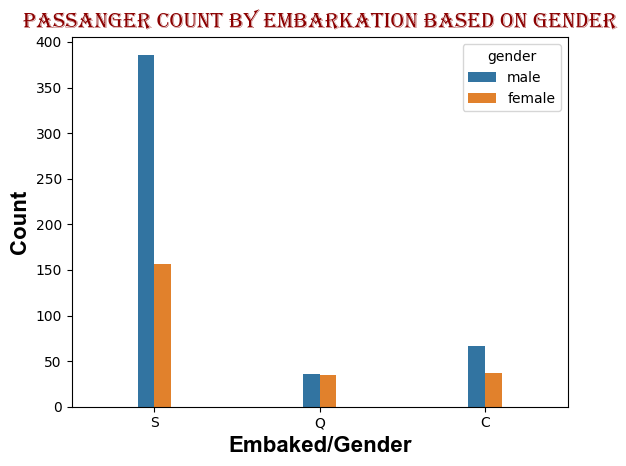

In [57]:
sns.countplot(x=df['embarked'],hue=df['gender'],width=.2)


title_font={
    'family':'Algerian',
    'size':16,
    'weight':'bold',
    'color':'darkred'
}
lable_font={
    'family':'Arial',
    'size':16,
    'weight':'bold',
    'color':'black'
}

plt.title("Passanger Count by Embarkation based on Gender",fontdict=title_font)
plt.xlabel("Embaked/Gender",fontdict=lable_font)
plt.ylabel("Count",fontdict=lable_font)
plt.show()

### **Insights**
- Southampton (S) had the most passengers, mostly males.
- Cherbourg (C) and Queenstown (Q)  had fewer passengers, with relatively more females at Cherbourg.



### **Summary of Titanic Dataset**


This project performs an exploratory data analysis (EDA) to examine survival outcomes among passengers. The analysis begins with an overview of the **count and percentage of survived and not survived passengers**, providing a general understanding of survival distribution.

Survival trends are then analyzed across **gender**, showing clear differences in survival rates between male and female passengers. Both absolute counts and percentage-based comparisons highlight how gender played a major role in survival outcomes.

The project further investigates survival based on **passenger type** (such as traveling alone or with family) and **passenger class**, revealing that higher classes and certain passenger types had better survival chances. Percentage-based survival comparisons strengthen these observations.

Fare analysis is conducted across **passenger class and passenger type**, demonstrating the relationship between fare amount and socio-economic status. Additional comparisons of fare with survival rates show that passengers who paid higher fares generally had a higher probability of survival.

Age-related analysis includes **age distribution**, **age versus fare**, and **age versus fare based on gender**, helping identify how age interacted with economic and demographic factors. The project also explores how survival rates varied with fare across **gender, passenger class, and passenger type**, along with their average fare values.

Family-related factors such as **siblings/spouses** and **parents/children aboard** are analyzed to understand how traveling with family influenced survival probability.

Finally, embarkation analysis evaluates **passenger count by embarkation port**, survival probability based on **embarked town**, and how embarkation patterns differ by gender. These insights show how location of boarding may be associated with survival outcomes.

Overall, the project provides a comprehensive understanding of how **demographics, economic status, family structure, and travel characteristics** collectively influenced passenger survival.


### **Conclusion**

This project clearly shows that passenger survival was influenced by several important factors rather than being random. Gender played a major role, with female passengers having a higher chance of survival. Passenger class and fare were also significant, as passengers in higher classes and those who paid higher fares generally survived at higher rates.

Age and family structure further affected survival outcomes. Children and younger passengers showed better survival chances, while passengers traveling with a small number of family members had higher survival rates compared to those traveling alone or with large families. Passenger type also influenced survival, highlighting differences between solo travelers and those traveling with family.

The analysis of embarkation ports revealed that survival probability varied depending on where passengers boarded the ship, mainly due to differences in passenger class, fare, and demographic composition.

Overall, this project demonstrates how exploratory data analysis helps uncover meaningful patterns in data. By analyzing multiple variables together, the project provides a better understanding of the factors that influenced survival and highlights the importance of data-driven insights in real-world decision-making.

